In [ ]:
# Tutorial 7 - Pandas, Numpy & Team Collaboration
### FINM3422 - Data Cleaning, Alignment, Multi‑Dataset Operations
---
This tutorial helps you build **real confidence** with Python, pandas, and numpy.
It is **not related to any assessment** - it builds generic modelling skills used in finance and data analysis.

You will:
- Clean small finance‑flavoured datasets
- Align dates & practice time‑series operations
- Merge DataFrames correctly
- Understand vectorisation vs loops
- Produce diagnostic charts
- Practice GitHub collaboration (branches + PRs) as a **team**

---

In [ ]:
change

## 1. Environment Info

In [2]:
import sys, pandas as pd, numpy as np
print('Python:', sys.version)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)

Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
pandas: 2.2.3
numpy: 2.2.3


## 2. Imports & Settings

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme()

## 3. Generate Synthetic Finance‑Flavoured Datasets (No CSVs Needed)
We will create three small datasets directly in this notebook.
Each series mimics simple monthly price or return behaviour.

### ✅ Dataset A — Monthly prices for Asset A
### ✅ Dataset B — Monthly prices for Asset B
### ✅ Dataset C — Monthly returns for Asset C

Later, you will clean, align, merge, and analyse them.

In [4]:
# Generate synthetic data
dates = pd.date_range(start='2021-01-01', periods=24, freq='M')

np.random.seed(0)
assetA = 100 * (1 + 0.01*np.random.randn(24)).cumprod()
assetB = 80 * (1 + 0.015*np.random.randn(24)).cumprod()
assetC_returns = np.random.normal(loc=0.01, scale=0.03, size=24)  # already returns

dfA = pd.DataFrame({'PriceA': assetA}, index=dates)
dfB = pd.DataFrame({'PriceB': assetB}, index=dates)
dfC = pd.DataFrame({'RetC': assetC_returns}, index=dates)

dfA.head()

C:\Users\oscar\AppData\Local\Temp\ipykernel_24940\2669516881.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2021-01-01', periods=24, freq='M')


,PriceA
2021-01-31,101.7641
2021-02-28,102.1713
2021-03-31,103.1713
2021-04-30,105.4832
2021-05-31,107.4532


## 4. Inspection Tasks — *Team Split*
Assign ONE task per teammate. Add conclusions in markdown.

### ✅ Tasks:
- Inspect `.info()` on one dataset
- Inspect `.describe()`
- Check for missing values using `.isna().sum()`
- Check index type
- Infer frequency using `pd.infer_freq()`
- Check for duplicated dates using `.duplicated()`

In [5]:
# Example cell — students create their own below
# Choose dataset
df = dfA.copy()

# Basic structure
print("INFO:")
df.info()

print("\nDESCRIBE:")
print(df.describe())

print("\nMISSING VALUES:")
print(df.isna().sum())

print("\nDUPLICATED DATES:")
print(df.index.duplicated().sum())

print("\nINDEX TYPE:")
print(type(df.index))

print("\nINFERRED FREQUENCY:")
print(pd.infer_freq(df.index))

INFO:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PriceA  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes

DESCRIBE:
        PriceA
count  24.0000
mean  108.5381
std     3.1491
min   101.7641
25%   107.2237
50%   109.1943
75%   110.7507
max   112.9085

MISSING VALUES:
PriceA    0
dtype: int64

DUPLICATED DATES:
0

INDEX TYPE:
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

INFERRED FREQUENCY:
ME


## 5. Cleaning Tasks — *Team Split*
### Why we clean data
Real datasets contain issues: inconsistent dates, missing observations, incorrect datatypes.
Finance models fail if the underlying data is misaligned or dirty.

### ✅ Tasks (each member gets one):
- Convert index to true month‑end using `.to_period('M').to_timestamp('M')`
- Sort index and verify ascending order
- Forward fill missing prices (if any)
- Convert prices → returns using `.pct_change().dropna()`
- Convert string columns → numeric (if needed)
- Rename columns to standardised names (e.g., `PriceA`, `PriceB`, `RetC`)
- Add markdown describing what issue you fixed and why

In [7]:

# Make copies so originals stay unchanged
cleanA = dfA.copy()
cleanB = dfB.copy()
cleanC = dfC.copy()

# 1. Convert dates to true month end
cleanA.index = cleanA.index.to_period("M").to_timestamp("M")
cleanB.index = cleanB.index.to_period("M").to_timestamp("M")
cleanC.index = cleanC.index.to_period("M").to_timestamp("M")

# 2. Sort index
cleanA = cleanA.sort_index()
cleanB = cleanB.sort_index()
cleanC = cleanC.sort_index()

# 3. Forward-fill missing prices
# Applies mainly to price data; harmless here even if no missing values exist
cleanA = cleanA.ffill()
cleanB = cleanB.ffill()

# 4. Convert price columns into returns
cleanA = cleanA.pct_change().dropna()
cleanB = cleanB.pct_change().dropna()

# 5. Convert any non-numeric columns to numeric
cleanA = cleanA.apply(pd.to_numeric, errors="coerce")
cleanB = cleanB.apply(pd.to_numeric, errors="coerce")
cleanC = cleanC.apply(pd.to_numeric, errors="coerce")

# 6. Rename columns for consistency
cleanA.columns = ["PriceA"]
cleanB.columns = ["PriceB"]
cleanC.columns = ["RetC"]

# Preview cleaned datasets
print("Cleaned dfA:")
print(cleanA.head())

print("\nCleaned dfB:")
print(cleanB.head())

print("\nCleaned dfC:")
print(cleanC.head())

Cleaned dfA:
            PriceA
2021-02-28  0.0040
2021-03-31  0.0098
2021-04-30  0.0224
2021-05-31  0.0187
2021-06-30 -0.0098

Cleaned dfB:
            PriceB
2021-02-28 -0.0218
2021-03-31  0.0007
2021-04-30 -0.0028
2021-05-31  0.0230
2021-06-30  0.0220

Cleaned dfC:
              RetC
2021-01-31 -0.0384
2021-02-28  0.0036
2021-03-31 -0.0169
2021-04-30  0.0216
2021-05-31 -0.0053


In [8]:
# combine datasets (optional)
df = pd.concat([cleanA, cleanB, cleanC], axis=1)
df.columns = ["RetA", "RetB", "RetC"]  # ensure consistency
df.head()

,RetA,RetB,RetC
2021-01-31,NaN,NaN,-0.0384
2021-02-28,0.0040,-0.0218,0.0036
2021-03-31,0.0098,0.0007,-0.0169
2021-04-30,0.0224,-0.0028,0.0216
2021-05-31,0.0187,0.0230,-0.0053


## 6. Time-Series Transformations 
### ✅ Compute simple monthly returns
### ✅ Wealth index
### ✅ Rolling averages/volatility
### ✅ Correlations between assets

These operations are used everywhere in finance, investment operations, and risk analysis.

In [10]:
# Returns for A and B
returns = df.copy()
returns.head()

# Wealth index
wealth_index = (1 + returns).cumprod()
wealth_index.head()

# rolling mean 
rolling_mean = returns.rolling(window=3).mean()
rolling_mean.head()

# rolling volatility
rolling_vol = returns.rolling(window=3).std()
rolling_vol.head()

# asset correlation
correlation_matrix = returns.corr()
correlation_matrix

,RetA,RetB,RetC
RetA,1.0000,-0.0902,0.1960
RetB,-0.0902,1.0000,-0.0239
RetC,0.1960,-0.0239,1.0000


In [ ]:
#plot (optional)
wealth_index.plot(title="Wealth Index")
plt.show()

rolling_mean.plot(title="3-Month Rolling Mean")
plt.show()

rolling_vol.plot(title="3-Month Rolling Volatility")
plt.show()

## 7. Merging / Joining Multiple DataFrames
Merging/joining datasets is crucial when combining sleeves, markets, or indicators.

### ✅ Try these joins:
- `inner` join
- `outer` join (shows missing dates if any)
- `left` join

Explain in markdown what difference you observed.

In [11]:
# inner join(only matching dates)
inner_join = cleanA.join([cleanB, cleanC], how='inner')
inner_join.head()

# outer join (keep all dates)
outer_join = cleanA.join([cleanB, cleanC], how='outer')
outer_join.head()

# left join (keep dates from A)
left_join = cleanA.join([cleanB, cleanC], how='left')
left_join.head()

# check missing dates
print("Inner NA:\n", inner_join.isna().sum())
print("\nOuter NA:\n", outer_join.isna().sum())
print("\nLeft NA:\n", left_join.isna().sum())


Inner NA:
 PriceA    0
PriceB    0
RetC      0
dtype: int64

Outer NA:
 PriceA    1
PriceB    1
RetC      0
dtype: int64

Left NA:
 PriceA    0
PriceB    0
RetC      0
dtype: int64


## 8. Vectorisation vs Loops
Vectorised operations in pandas/numpy are *much faster* than Python loops.
This matters in finance where datasets can be millions of rows.

### ✅ Compare performance, clarity, correctness.

In [12]:
# Loop version (slow)
%%timeit
out = []
for r in returnsA['PriceA']:
    out.append(r * 12)  # e.g., annualising monthly return (not exact)
loop_res = pd.Series(out, index=returnsA.index)

UsageError: Line magic function `%%timeit` not found.


In [ ]:
# Vectorised version (fast)
%%timeit
vec_res = returnsA['PriceA'] * 12

## 9. Diagnostic Charts
Producing visual checks helps reveal missing data, misalignment, noise, or unusual movements.
Each team member creates **one chart**.

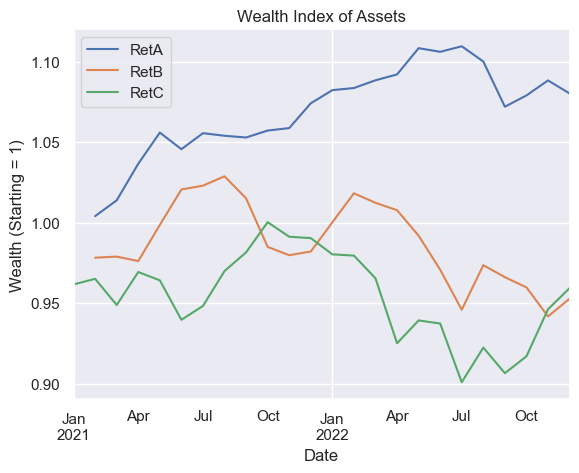

In [13]:
wealth_index = (1 + df).cumprod()

wealth_index.plot(title="Wealth Index of Assets")
plt.xlabel("Date")
plt.ylabel("Wealth (Starting = 1)")
plt.show()

## 10. Team GitHub Workflow — Feature Branches & PRs

Each student:
1. Create a branch: `feature/t7_name_task`
2. Complete their assigned notebook task
3. Stage → Commit → Push (GUI only)
4. Open a Pull Request in the tutorial-team repo
5. Request review

Team lead:
- Reviews PRs
- Merges when safe
- Runs ‘Run All’ to check final notebook
- Pushes clean version


## 11. Final Checks Before Leaving

✅ Notebook runs top-to-bottom (Run All)
✅ No merge conflicts
✅ Data is clean
✅ Charts work
✅ All team PRs merged into `main`

---
**End of Tutorial 7 — Great work!**